# EDA of raw data (Ru Sentiment Analysis)

## Goal: explore the raw data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Uploading data

In [2]:
df = pd.read_csv('../data/interim/data_read.csv')
df.head()

,Комментарии,Эмоциональная окраска
0,Уже регестрировалась,Нейтральная
1,Вам зачем местоположение?,Нейтральная
2,Видео нет,Негативная
3,конченые.,Негативная
4,зачем мне это?,Нейтральная


### General info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29057 entries, 0 to 29056
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Комментарии            29056 non-null  object
 1   Эмоциональная окраска  29057 non-null  object
dtypes: object(2)
memory usage: 454.1+ KB


In [4]:
df.shape

(29057, 2)

In [5]:
df.describe()

,Комментарии,Эмоциональная окраска
count,29056,29057
unique,23315,5
top,все,Негативная
freq,315,12523


In [6]:
dict_columns = {'Комментарии':'comment', 'Эмоциональная окраска':'label'}
df.rename(columns = dict_columns, inplace = True)

In [7]:
df.columns

Index(['comment', 'label'], dtype='object')

### Gaps

In [8]:
df.isna().sum()

comment    1
label      0
dtype: int64

In [9]:
df[df.isna().any(axis=1)]

,comment,label
16250,NaN,Позитивная


In [10]:
df.dropna()

,comment,label
0,Уже регестрировалась,Нейтральная
1,Вам зачем местоположение?,Нейтральная
2,Видео нет,Негативная
3,конченые.,Негативная
4,зачем мне это?,Нейтральная
...,...,...
29052,ставлю 5 звёзд!!приложение хорошее!\nно есть о...,Нейтральная
29053,Как загрузить видео короткое? Пишет что загруз...,Негативная
29054,Сделайте пожалуйста чтобы не водить пароль и л...,Негативная
29055,"Ни чего не меняется, как выкидывало из акаунта...",Негативная


### Label distribution

In [11]:
df['label'].value_counts()

label
Негативная     12523
Позитивная      7726
Мусор           4973
Нейтральная     3833
позитивная         2
Name: count, dtype: int64

In [12]:
df[df['label']=='позитивная']

,comment,label
17197,Рутибе самая лучшая платформа в мире,позитивная
22973,"В целом приложение отличное, рекомендую",позитивная


In [13]:
df.loc[df['label'] == 'позитивная','label'] = 'Позитивная'

In [14]:
df['label'].value_counts()

label
Негативная     12523
Позитивная      7728
Мусор           4973
Нейтральная     3833
Name: count, dtype: int64

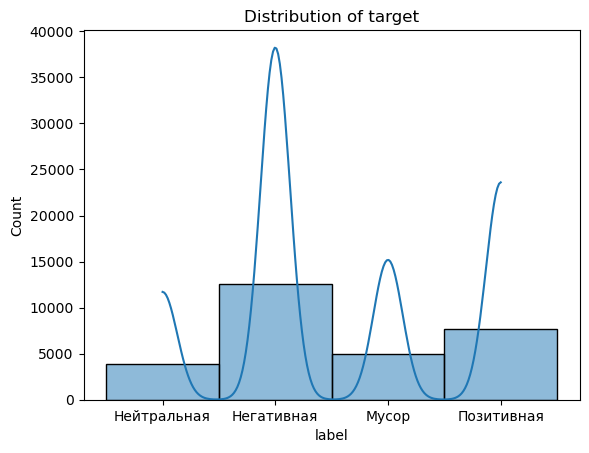

In [15]:
sns.histplot(df['label'], bins=4, kde=True)
plt.title('Distribution of target')
plt.show()

### Text analysis

In [16]:
df['comment'].str.len().describe()

count    29056.000000
mean        77.718750
std        134.538179
min          1.000000
25%         10.000000
50%         29.000000
75%         93.000000
max      10824.000000
Name: comment, dtype: float64

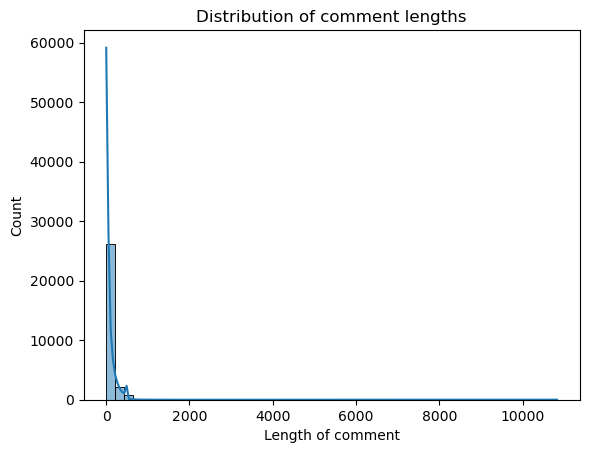

In [17]:
sns.histplot(df['comment'].str.len(), bins=50,kde=True)
plt.title('Distribution of comment lengths')
plt.xlabel('Length of comment')
plt.ylabel('Count')
plt.show()

### Outliers

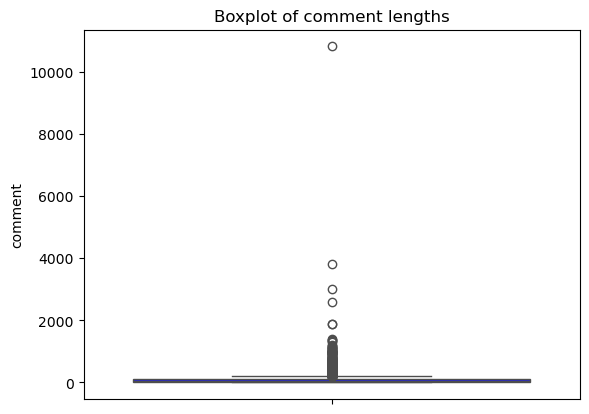

In [18]:
sns.boxplot(y=df['comment'].str.len(),color = 'blue')
plt.title('Boxplot of comment lengths')
plt.show()

In [19]:
q = df['comment'].str.len().quantile(0.99)
q

np.float64(497.0)

In [20]:
df[df['comment'].str.len()<q]

,comment,label
0,Уже регестрировалась,Нейтральная
1,Вам зачем местоположение?,Нейтральная
2,Видео нет,Негативная
3,конченые.,Негативная
4,зачем мне это?,Нейтральная
...,...,...
29052,ставлю 5 звёзд!!приложение хорошее!\nно есть о...,Нейтральная
29053,Как загрузить видео короткое? Пишет что загруз...,Негативная
29054,Сделайте пожалуйста чтобы не водить пароль и л...,Негативная
29055,"Ни чего не меняется, как выкидывало из акаунта...",Негативная


In [21]:
df = df[df['comment'].str.len()<q]

In [22]:
df['comment'].str.len().describe()

count    28742.000000
mean        71.342252
std         98.821404
min          1.000000
25%         10.000000
50%         28.000000
75%         90.000000
max        496.000000
Name: comment, dtype: float64

## Conclusions

-No significant class imbalance observed

-Small number of missing values removed

-Outliers detected and removed

-Target label “позитивная” standardized to “Позитивная”